In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats

# Poisson inputs at theta frequency with and without electric field (TI): single run analysis

In [2]:
idx = "5"

file_labels = {
    "No TI": "no_ti/0",
    "5 Hz": "1000/90_90_5",
    "130 Hz": "1000/90_90_130"
}

output_dir = f"output/temporal-interference/poisson_theta/{idx}"

colors = {
    "No TI": "steelblue",
    "5 Hz": "lightcoral",
    "130 Hz": "mediumseagreen"
}

## Membrane potential traces

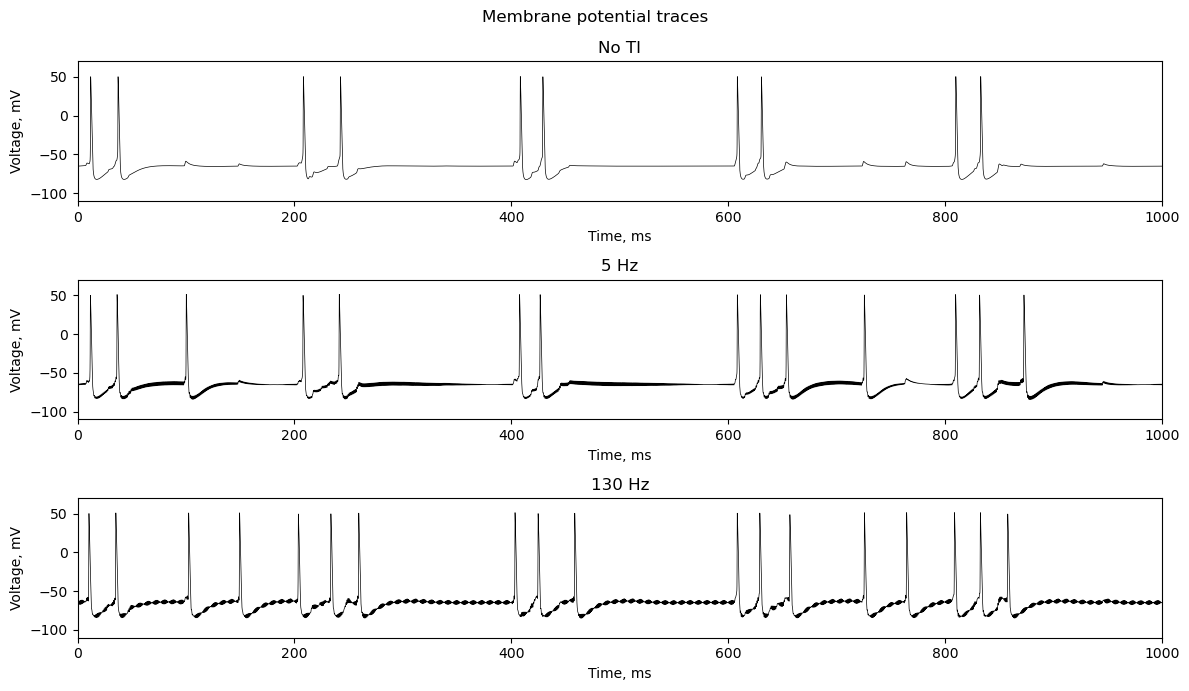

In [3]:
fig, axs = plt.subplots(nrows = 3, ncols = 1, figsize = (12, 7))

for i, label in enumerate(file_labels.keys()):
    voltage = pd.read_csv(f"{output_dir}/{file_labels[label]}/voltage.csv")
    
    axs[i].plot(
        voltage.Time,
        voltage.Voltage,
        linewidth = 0.5,
        color = "black"
    )

    axs[i].set_xlabel("Time, ms")
    axs[i].set_ylabel("Voltage, mV")

    axs[i].set_xlim(0, 1000)
    axs[i].set_ylim(-110, 70)
    
    axs[i].set_title(label)

fig.suptitle("Membrane potential traces")
fig.tight_layout()

plt.show()

## Spiking frequency patterns

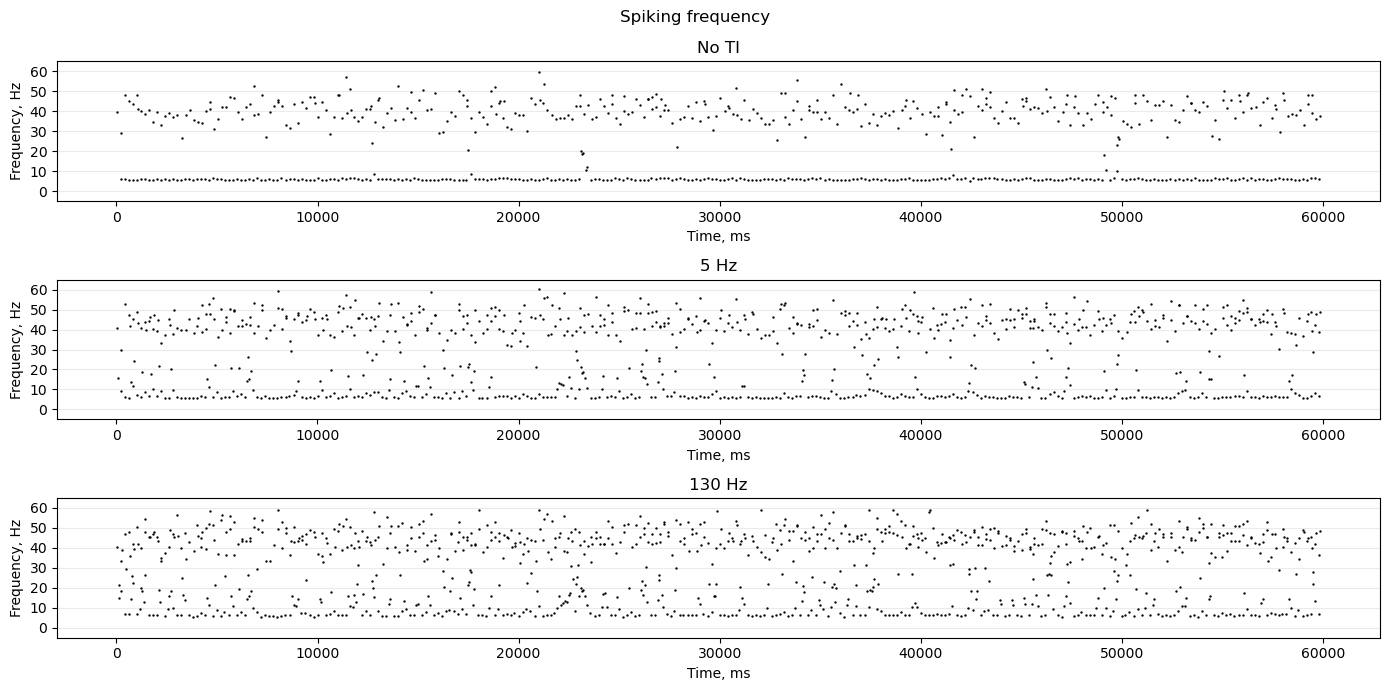

In [4]:
fig, axs = plt.subplots(nrows = 3, ncols = 1, figsize = (14, 7))

for i, label in enumerate(file_labels.keys()):
    spike_frequency = pd.read_csv(f"{output_dir}/{file_labels[label]}/spike_frequency.csv")

    axs[i].scatter(
        spike_frequency.Time,
        spike_frequency.Frequency,
        s = 0.5,
        color = "black",
        zorder = 3
    )

    axs[i].grid(axis = "y", zorder = 0, alpha = 0.25)
    axs[i].set_xlabel("Time, ms")
    axs[i].set_ylabel("Frequency, Hz")
    axs[i].set_ylim(-5, 65)
    axs[i].set_yticks(np.arange(0, 65, 10))
    axs[i].set_title(label)

fig.suptitle("Spiking frequency")
fig.tight_layout()

plt.show()

In [5]:
def calculate_spike_times(spike_frequency):
    spike_times = spike_frequency.Time.values
    np.insert(spike_times, 0, spike_frequency.Time[0] - 1000 / spike_frequency.Frequency[0])

    return spike_times

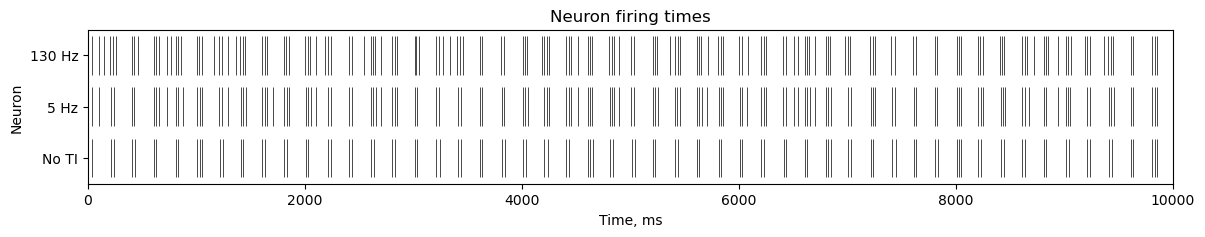

In [6]:
plt.figure(figsize = (14, 2))

for i, label in enumerate(file_labels.keys()):
    spike_frequency = pd.read_csv(f"{output_dir}/{file_labels[label]}/spike_frequency.csv")
    spike_times = calculate_spike_times(spike_frequency)
    plt.eventplot(spike_times, lineoffsets = i + 1, linelengths = 0.75, colors = "black", linewidths = 0.5)

plt.ylim(0.5, 3.5)
plt.ylabel("Neuron")
plt.yticks(np.arange(1, 4, 1), ["No TI", "5 Hz", "130 Hz"])

plt.xlabel("Time, ms")
plt.xlim(0, 10000)

plt.title("Neuron firing times")
plt.show()

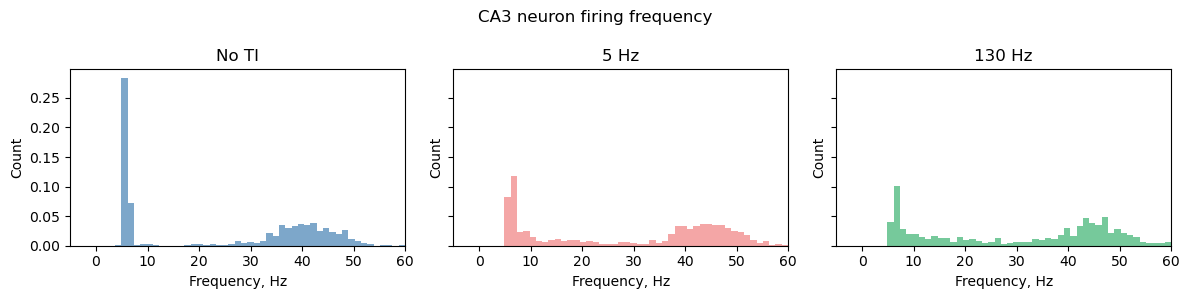

In [7]:
fig, axs = plt.subplots(nrows = 1, ncols = 3, figsize = (12, 3), sharey = True)

min = 0
max = 60

bin_edges = np.linspace(min, max, num = 50)

for i, label in enumerate(file_labels.keys()):
    spike_frequency = pd.read_csv(f"{output_dir}/{file_labels[label]}/spike_frequency.csv").Frequency
    axs[i].hist(spike_frequency, bins = bin_edges, alpha = 0.7, color = colors[label], density = True)
    
    axs[i].set_ylabel("Count")
    axs[i].set_xlabel("Frequency, Hz")
    axs[i].set_xlim(-5, max)
    axs[i].set_title(label)

fig.suptitle("CA3 neuron firing frequency")
fig.tight_layout()
plt.show()

## Interspike intervals (ISI)

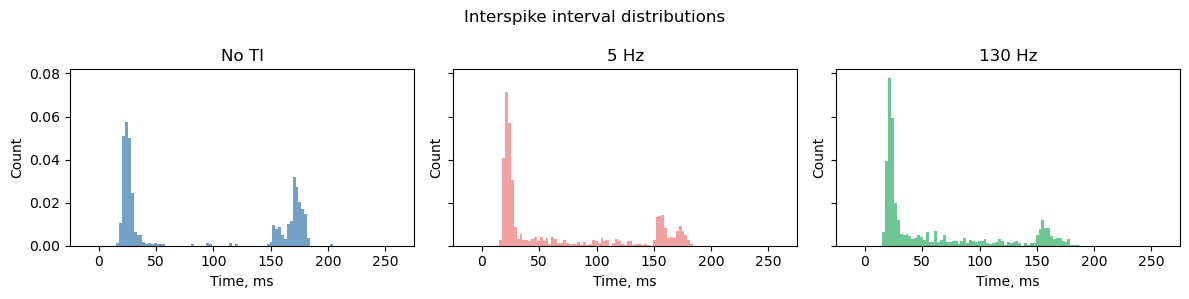

In [8]:
fig, axs = plt.subplots(nrows = 1, ncols = 3, figsize = (12, 3), sharey = True)

min = 0
max = 250

bin_edges = np.linspace(min, max, num = 100)

for i, label in enumerate(file_labels.keys()):
    spike_frequency = pd.read_csv(f"{output_dir}/{file_labels[label]}/spike_frequency.csv")
    spike_times = calculate_spike_times(spike_frequency)
    isi = np.diff(spike_times)
    
    loc, scale = stats.expon.fit(isi)

    axs[i].hist(isi, bins = bin_edges, density = True, alpha = 0.75, label = label, color = colors[label])

    axs[i].set_xlabel("Time, ms")
    axs[i].set_ylabel("Count")
    axs[i].set_title(label)
    axs[i].set_xlim(min - max * 0.1, max * 1.1)

fig.suptitle("Interspike interval distributions")
fig.tight_layout()
plt.show()

## Synaptic weights

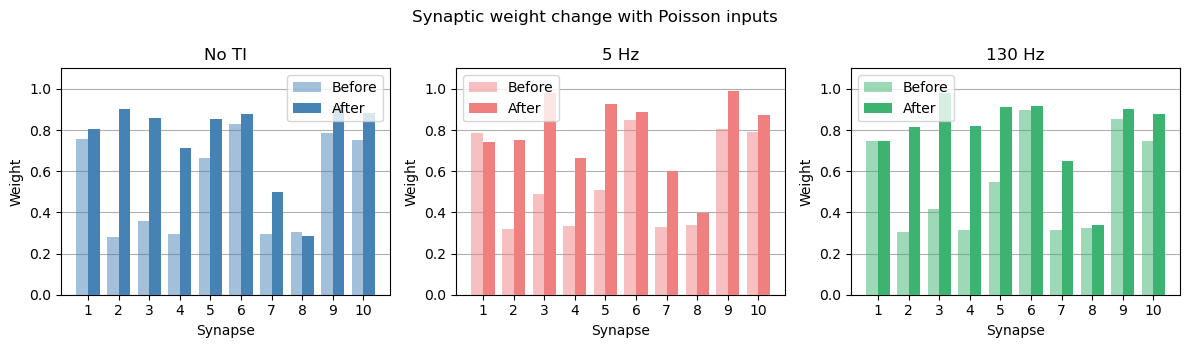

In [9]:
fig, axs = plt.subplots(nrows = 1, ncols = 3, figsize = (12, 3.5))

for i, label in enumerate(file_labels.keys()):
    syn_weights = pd.read_csv(f"{output_dir}/{file_labels[label]}/synapse_weights.csv")

    initial_weights = syn_weights.iloc[0][2:]
    synapse_weights = syn_weights.iloc[-1][2:]
    synapses = np.arange(0, 10) + 1

    axs[i].grid(axis = "y", zorder = 0)
    axs[i].bar(synapses - 0.19, initial_weights, color = colors[label], zorder = 3, alpha = 0.5, width = 0.38, label = "Before")
    axs[i].bar(synapses + 0.19, synapse_weights, color = colors[label], zorder = 3, width = 0.38, label = "After")
    axs[i].set_ylim(0, 1.1)
    axs[i].set_title(label)
    axs[i].set_xticks(synapses)
    axs[i].set_xticklabels(synapses)
    axs[i].legend()
    axs[i].set_xlabel("Synapse")
    axs[i].set_ylabel("Weight")

fig.suptitle("Synaptic weight change with Poisson inputs")
fig.tight_layout()
plt.show()

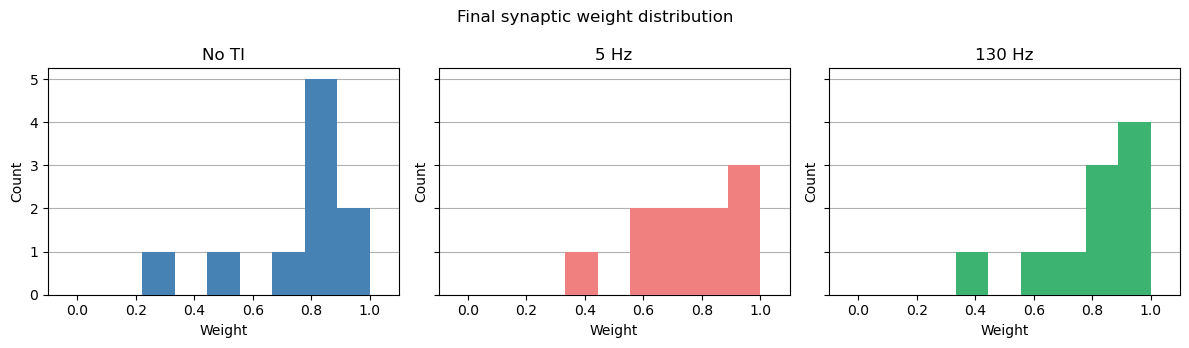

In [10]:
fig, axs = plt.subplots(nrows = 1, ncols = 3, figsize = (12, 3.5), sharey = True)

bin_edges = np.linspace(0, 1, num = 10)

for i, label in enumerate(file_labels.keys()):
    syn_weights = pd.read_csv(f"{output_dir}/{file_labels[label]}/synapse_weights.csv")
    synapse_weights = syn_weights.iloc[-1][2:]

    axs[i].grid(axis = "y", zorder = 0)
    axs[i].hist(synapse_weights, color = colors[label], zorder = 3, bins = bin_edges)
    axs[i].set_title(label)
    axs[i].set_xlabel("Weight")
    axs[i].set_ylabel("Count")
    axs[i].set_xlim(-0.1, 1.1)

fig.suptitle("Final synaptic weight distribution")
fig.tight_layout()
plt.show()

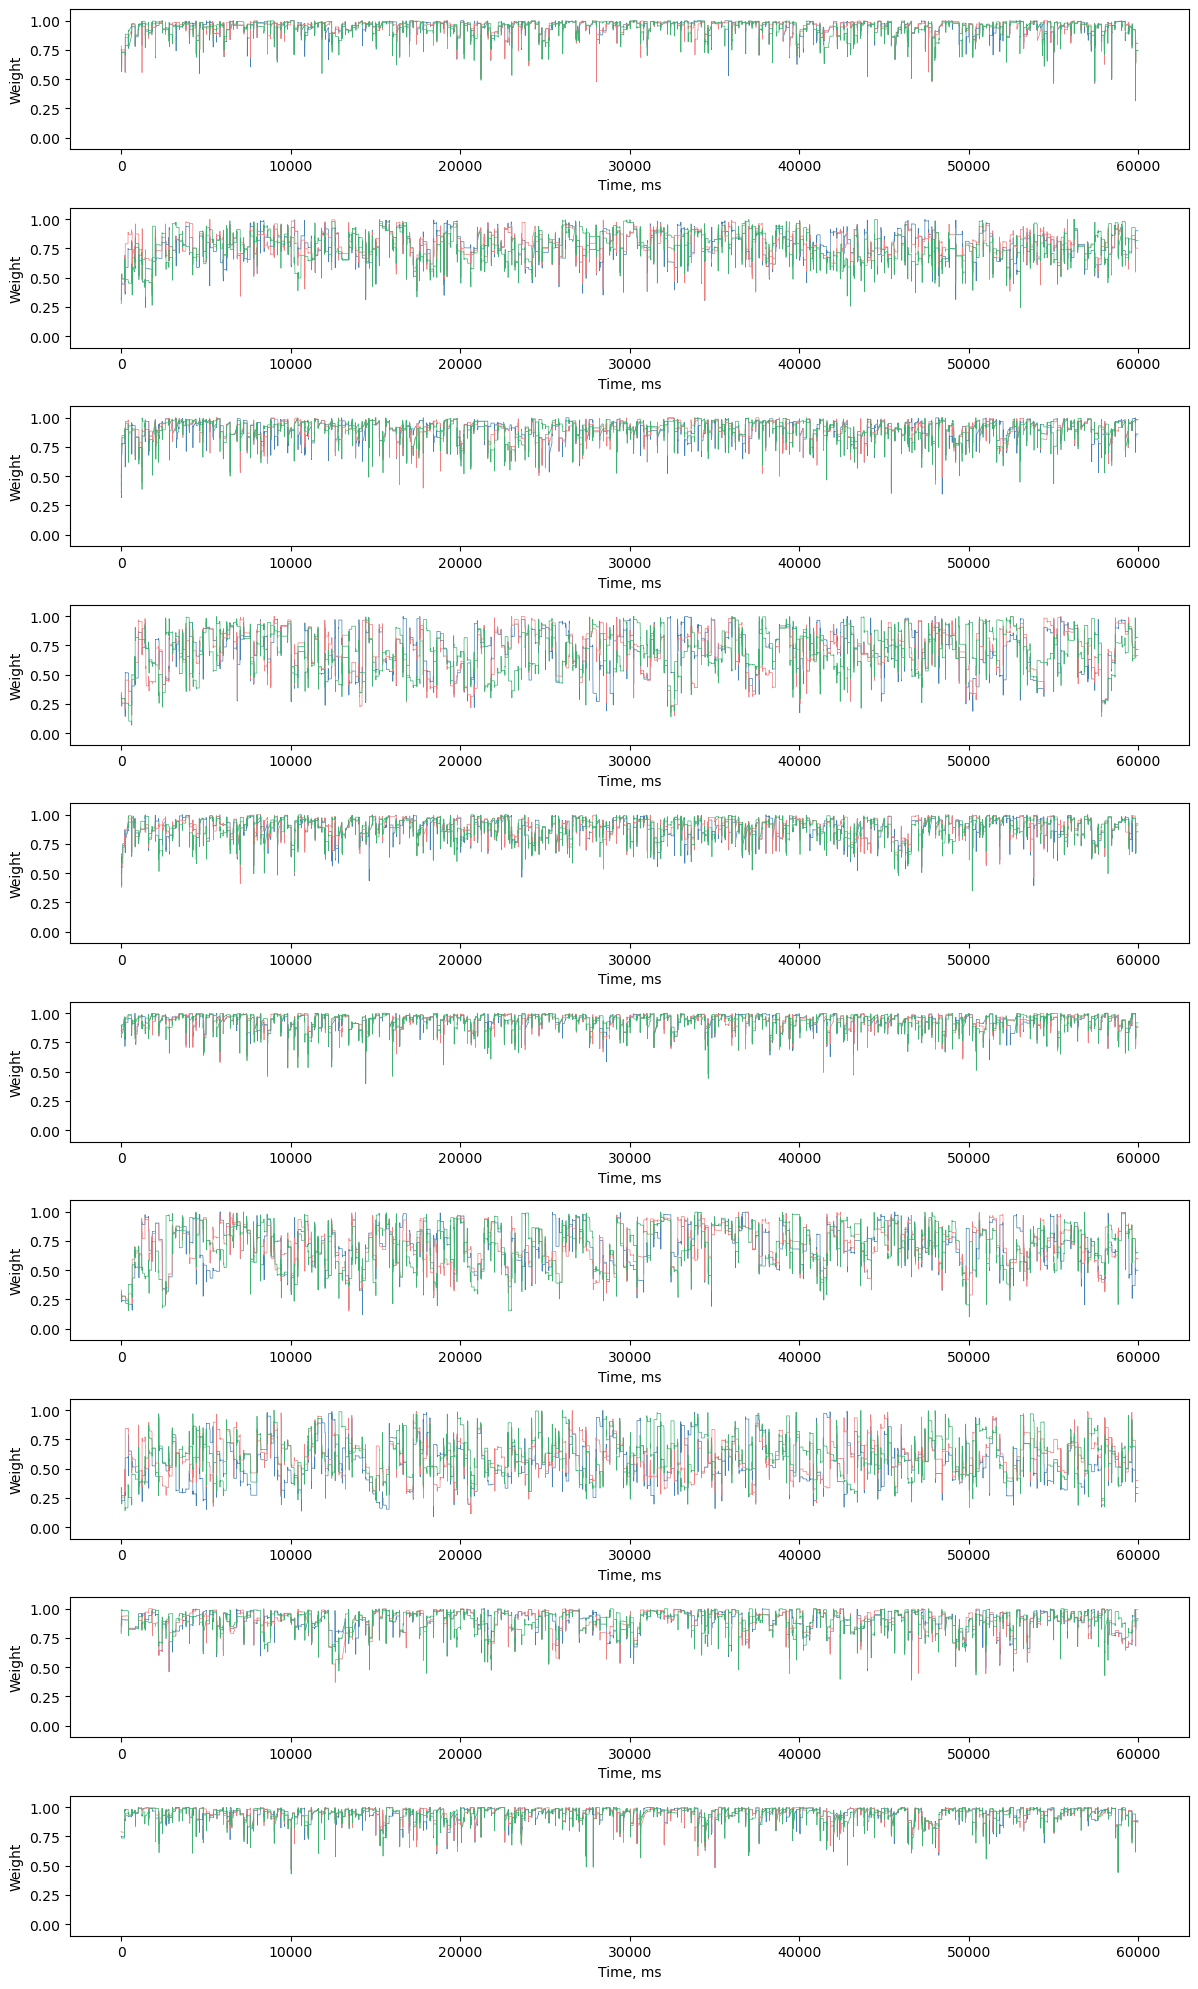

In [11]:
n_synapses = 10
fig, axs = plt.subplots(nrows = n_synapses, ncols = 1, figsize = (12, 2 * n_synapses))

for i, label in enumerate(file_labels.keys()):
    syn_weights = pd.read_csv(f"{output_dir}/{file_labels[label]}/synapse_weights.csv")

    for j in range(n_synapses):
        axs[j].plot(syn_weights.Time, syn_weights[f"Synapse{j}"], linewidth = 0.5, color = colors[label], label = label)
        axs[j].set_xlabel("Time, ms")
        axs[j].set_ylabel("Weight")
        axs[j].set_ylim(-0.1, 1.1)

fig.tight_layout()
plt.show()